In [1]:
import sys; print(sys.executable)

C:\Users\elifa\Documents\GitHub\NOROM_Inv_Pendulum\.venv\Scripts\python.exe


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, stats

# --- yol cozumu: notebook Notebooks/ altindan da, Data Analysis/ altindan da calisir
# Aktif veri seti. config.yaml -> datasets ile ayni isimler.
DATASET = "pilot2"

def _interim(dataset):
    for base in [Path.cwd(), *Path.cwd().parents]:
        p = base / "data" / dataset / "interim"
        if p.is_dir():
            return p
    raise FileNotFoundError(f"data/{dataset}/interim bulunamadi")

INTERIM = _interim(DATASET)

# Guvenilirlik hesabi (varyans ayrisimi, ICC, split-half) NB92'de yazilmisti,
# src/reliability.py'ye tasindi. Kopyalanmiyor, import ediliyor.
ANALYSIS_ROOT = Path.cwd()
while not (ANALYSIS_ROOT / "config.yaml").exists():
    if ANALYSIS_ROOT == ANALYSIS_ROOT.parent:
        raise FileNotFoundError("config.yaml bulunamadi")
    ANALYSIS_ROOT = ANALYSIS_ROOT.parent
sys.path.insert(0, str(ANALYSIS_ROOT))

from src.reliability import (decompose, cell_table, split_half_stats,
                             N_SPLIT_DEFAULT)

# --- bu notebook'a ozel sabitler (config.yaml'a DEGIL, izole kalsin)
FS        = 60.0                      # ornekleme, Hz
COND      = ["no_noise", "N1", "N2", "N3", "N4"]
MIN_SEG   = 256                       # ~4.3 s; daha kisa segmentte spektrum guvenilir degil
BAND      = (0.05, 10.0)              # medyan frekansin arandigi bant
SAMPEN_M  = 2                         # sablon uzunlugu
SAMPEN_R  = 0.2                       # tolerans = SAMPEN_R * sd
NEUTRAL   = 0.02                      # config.yaml build.input_neutral_band ile ayni

LIN  = np.array([-2, -1,  0,  1, 2], float)   # lineer kontrast agirliklari
QUAD = np.array([ 2, -1, -2, -1, 2], float)   # kuadratik kontrast agirliklari

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("interim:", INTERIM)

interim: C:\Users\elifa\Documents\GitHub\NOROM_Inv_Pendulum\Data Analysis\data\pilot2\interim


## 1. Ölçüt tanımları

`sampen` elle yazıldı, dışarıdan paket gerektirmesin diye. Richman & Moorman 2000'deki tanım:
uzunluğu m olan pencerelerden birbirine `r` toleransı içinde benzeyen çiftlerin kaçı m+1'e
uzatılınca da benziyor. Oran yüksekse seri öngörülebilir, entropy düşük.

In [3]:
def sampen(x, m=SAMPEN_M, r_frac=SAMPEN_R):
    """Sample entropy (Richman & Moorman 2000, Am J Physiol 278:H2039)."""
    x = np.asarray(x, float)
    n = len(x)
    if n < m + 2:
        return np.nan
    sd = x.std(ddof=0)
    if sd == 0:
        return np.nan
    r = r_frac * sd

    def _count(mm):
        k = n - mm + 1
        emb = np.lib.stride_tricks.sliding_window_view(x, mm)[:k]
        c = 0
        for i in range(k - 1):
            d = np.max(np.abs(emb[i + 1:] - emb[i]), axis=1)
            c += np.count_nonzero(d <= r)
        return c

    B, A = _count(m), _count(m + 1)
    if B == 0 or A == 0:
        return np.nan
    return -np.log(A / B)


def median_freq(x, fs=FS, nperseg=256, band=BAND):
    """Gucun yarisinin altinda kaldigi frekans (Welch spektrumu uzerinden)."""
    f, p = signal.welch(signal.detrend(x), fs=fs, nperseg=min(nperseg, len(x)))
    k = (f >= band[0]) & (f <= band[1])
    f, p = f[k], p[k]
    if p.sum() <= 0:
        return np.nan
    return float(np.interp(0.5, np.cumsum(p) / p.sum(), f))

## 2. Trial düzeyi hesap

Segment birimi **episode** (reset'ten reset'e). Trial içindeki `active` örnekleri uç uca
eklemek sahte sıçrama üretirdi; episode zaten kesintisiz olan doğal birim.

`MIN_SEG`'den kısa episode'lar atılıyor. Trial değeri, segmentlerin uzunlukla ağırlıklı
ortalaması.

Bu hücre ~1-2 dakika sürüyor (SampEn O(N²)).

In [4]:
s = pd.read_parquet(INTERIM / "samples_built.parquet")
s = s[(s.analysis_include) & (s.practice == 0)].copy()
print(f"analiz ornegi: {len(s):,} satir")

n_total = s.groupby(["participant_id", "trial_id"]).ngroups

rows = []
for (pid, tid), g in s.groupby(["participant_id", "trial_id"], sort=False):
    segs = [gs for _, gs in g.groupby("episode", sort=False) if len(gs) >= MIN_SEG]
    if not segs:
        continue
    w = np.array([len(x) for x in segs], float)

    def wavg(v):
        v = np.asarray(v, float)
        k = ~np.isnan(v)
        return float(np.average(v[k], weights=w[k])) if k.any() else np.nan

    u   = g.input_applied.values
    act = np.abs(u) > NEUTRAL
    rows.append(dict(
        participant_id=pid, trial_id=tid, noise_level_id=g.noise_level_id.iloc[0],
        n_seg=len(segs),
        medfreq_angle=wavg([median_freq(x.pole_angle_deg.values)  for x in segs]),
        medfreq_input=wavg([median_freq(x.input_applied.values)   for x in segs]),
        sampen_angle =wavg([sampen(x.pole_angle_deg.values)       for x in segs]),
        sampen_input =wavg([sampen(x.input_applied.values)        for x in segs]),
        # Cart tarafi. cart_velocity_m_s'te her segmentin ILK ornegi atiliyor:
        # reset'te hizlar sifirlanmadigi icin o ornek bir onceki episode'un son
        # hizini tasiyor, ve bu tek orneklik sicrama hem sampen'i hem spektrumu
        # bozuyor. cart_position_m'de boyle bir sicrama yok, orada atilmiyor.
        medfreq_cartpos=wavg([median_freq(x.cart_position_m.values)       for x in segs]),
        sampen_cartpos =wavg([sampen(x.cart_position_m.values)            for x in segs]),
        medfreq_cartvel=wavg([median_freq(x.cart_velocity_m_s.values[1:]) for x in segs]),
        sampen_cartvel =wavg([sampen(x.cart_velocity_m_s.values[1:])      for x in segs]),
        duty_cycle=float(act.mean()),
        amp_mean=float(np.abs(u[act]).mean()) if act.any() else np.nan,
    ))

trial = pd.DataFrame(rows)
print(f"trial tablosu: {trial.shape[0]} trial ({n_total} measurement trial'in "
      f"{n_total - trial.shape[0]} tanesinde MIN_SEG'den uzun episode yok)")
trial.head()

analiz ornegi: 600,000 satir


trial tablosu: 488 trial (500 measurement trial'in 12 tanesinde MIN_SEG'den uzun episode yok)


,participant_id,trial_id,noise_level_id,n_seg,medfreq_angle,medfreq_input,sampen_angle,sampen_input,medfreq_cartpos,sampen_cartpos,medfreq_cartvel,sampen_cartvel,duty_cycle,amp_mean
0,P001,T007,no_noise,1,0.234375,1.653383,0.070856,0.039852,0.234375,0.034948,0.234375,0.039936,0.176667,0.713706
1,P001,T011,N2,1,0.234375,1.212069,0.054241,0.023845,0.234375,0.048513,0.234375,0.021700,0.197500,0.562592
2,P001,T014,N1,2,0.234375,1.339870,0.090586,0.052861,0.234375,0.023020,0.234375,0.076778,0.283333,0.673196
3,P001,T015,no_noise,1,0.418417,0.636269,0.075790,0.044703,0.338624,0.062302,0.421548,0.059817,0.308333,0.582905
4,P001,T016,N3,1,0.330389,0.602605,0.021281,0.068998,0.234375,0.029853,0.288526,0.037130,0.340833,0.529168


### Aksiyonlar arası süre

`input_events` tablosundaki `onset` olayları: kolun nötr banddan çıktığı anlar.
Ardışık onset'ler arasındaki süre, kişinin düzeltme ritminin doğrudan ölçüsü.

In [5]:
ev = pd.read_parquet(INTERIM / "input_events.parquet")
ev = ev[(ev.practice == 0) & (ev.event == "onset")]

iai = []
for (pid, tid), g in ev.groupby(["participant_id", "trial_id"], sort=False):
    t = np.sort(g.t_trial_s.values)
    d = np.diff(t)
    d = d[d > 0]
    if len(d) < 2:
        continue
    iai.append(dict(participant_id=pid, trial_id=tid,
                    iai_median=float(np.median(d)),
                    iai_cv=float(d.std(ddof=1) / d.mean()),
                    onset_rate=float(len(t) / 20.0)))

trial = trial.merge(pd.DataFrame(iai), on=["participant_id", "trial_id"], how="left")

METRICS = ["medfreq_angle", "medfreq_input", "sampen_angle", "sampen_input",
           "medfreq_cartpos", "sampen_cartpos",
           "medfreq_cartvel", "sampen_cartvel",
           "duty_cycle", "amp_mean", "iai_median", "iai_cv", "onset_rate"]

pc = trial.groupby(["participant_id", "noise_level_id"])[METRICS].mean().reset_index()
print("katilimci x kosul:", pc.shape)

katilimci x kosul: (50, 15)


## 3. Kontrast testleri

Zincirin geri kalanıyla aynı makine. Her katılımcı için lineer ve kuadratik kontrast skoru
hesaplanıp, o 12 skorun sıfırdan farklı olup olmadığı Wilcoxon signed-rank ile sınanıyor.

In [6]:
def contrast(pc, metric):
    w = pc.pivot(index="participant_id", columns="noise_level_id",
                 values=metric)[COND].dropna()
    lin, quad = w.values @ LIN, w.values @ QUAD
    return dict(
        metrik=metric, n=len(w),
        **{c: round(w[c].mean(), 4) for c in COND},
        friedman_p=round(float(stats.friedmanchisquare(*w.values.T).pvalue), 4),
        lineer=round(lin.mean(), 4),
        lineer_p=round(float(stats.wilcoxon(lin).pvalue), 4),
        lin_ayni_yon=int(max((lin > 0).sum(), (lin < 0).sum())),
        kuadratik=round(quad.mean(), 4),
        kuadratik_p=round(float(stats.wilcoxon(quad).pvalue), 4),
    )

res = pd.DataFrame([contrast(pc, m) for m in METRICS])
pd.set_option("display.width", 200)
print("KOSUL ORTALAMALARI\n")
print(res[["metrik", "n"] + COND].to_string(index=False))

KOSUL ORTALAMALARI

         metrik  n  no_noise     N1     N2     N3     N4
  medfreq_angle 10    0.2563 0.2496 0.2647 0.2510 0.2542
  medfreq_input 10    1.5572 1.5962 1.5285 1.6641 1.5659
   sampen_angle 10    0.0791 0.0819 0.0800 0.0819 0.0768
   sampen_input 10    0.0545 0.0546 0.0543 0.0555 0.0557
medfreq_cartpos 10    0.2399 0.2367 0.2381 0.2352 0.2398
 sampen_cartpos 10    0.0239 0.0264 0.0259 0.0247 0.0237
medfreq_cartvel 10    0.3086 0.3066 0.3242 0.2995 0.3060
 sampen_cartvel 10    0.0641 0.0602 0.0608 0.0627 0.0612
     duty_cycle 10    0.2216 0.2215 0.2247 0.2214 0.2286
       amp_mean 10    0.4193 0.4175 0.4219 0.4208 0.4099
     iai_median 10    0.7423 0.7198 0.7293 0.7291 0.7306
         iai_cv 10    0.7252 0.7223 0.7415 0.7287 0.7497
     onset_rate 10    1.1250 1.1129 1.1036 1.1265 1.1116


In [7]:
print("KONTRAST TESTLERI\n")
print(res[["metrik", "friedman_p", "lineer", "lineer_p", "lin_ayni_yon",
           "kuadratik", "kuadratik_p"]].to_string(index=False))

KONTRAST TESTLERI

         metrik  friedman_p  lineer  lineer_p  lin_ayni_yon  kuadratik  kuadratik_p
  medfreq_angle      0.0646 -0.0027    0.8457             5    -0.0090       0.5566
  medfreq_input      0.6339  0.0854    0.4922             5    -0.0711       0.6953
   sampen_angle      0.5121 -0.0045    0.8457             6    -0.0119       0.3223
   sampen_input      0.9037  0.0033    0.5566             6     0.0018       0.6953
medfreq_cartpos      0.0271 -0.0016    0.5469             6     0.0112       0.2031
 sampen_cartpos      0.1819 -0.0022    0.5566             6    -0.0077       0.0645
medfreq_cartvel      0.0270 -0.0122    0.5566             6    -0.0252       0.3750
 sampen_cartvel      0.7358 -0.0033    0.5566             6     0.0060       0.5566
     duty_cycle      0.9885  0.0140    0.5566             5     0.0080       0.6250
       amp_mean      0.1338 -0.0155    0.8457             5    -0.0237       0.1309
     iai_median      0.5918 -0.0139    0.6953            

**Çoklu karşılaştırma uyarısı.** Dokuz ölçüt sınandı. Holm düzeltmesi uygulanınca
hiçbiri ayakta kalmıyor: en küçük p bile 9 ile çarpılınca 0.05'i geçiyor. Aşağıdaki
p < 0.05 satırları **keşif bulgusu**, doğrulanmış sonuç değil.

### Holm düzeltmesi neden üç ayrı aile

Üç test ailesi var ve her biri **farklı bir şekil hipotezi** soruyor:

- **Friedman** omnibus: koşullar arasında herhangi bir fark var mı.
- **Lineer kontrast**: etki koşul sırası boyunca monoton mu.
- **Kuadratik kontrast**: ters U var mı.

Bunlar birbirinin yerine geçen testler değil; biri reddedilince diğeri otomatik
reddedilmiyor, biri ayakta kalınca diğeri desteklenmiyor. Üçünü tek aile sayıp 3 × 13 = 39
test üzerinden düzeltmek, sorulmayan soruların cezasını sorulan soruya yüklemek olurdu.
Aile **içindeki** 13 ölçüt ise gerçekten eş zamanlı sınanıyor ve hepsi aynı soruyu aynı
veride soruyor; düzeltme oraya ait.

Yani: her aile kendi içinde 13 ölçüt üzerinden Holm. Düzeltme şeması sonradan keyfi
görünmesin diye gerekçesi burada duruyor.

In [8]:
# Holm duzeltmesi uc AYRI aile uzerinden, her biri kendi icinde len(res) olcut.
# Gerekce icin ustteki markdown hucresine bak.
def holm(p):
    p = np.asarray(p, float)
    out = np.empty_like(p)
    run = 0.0
    for i, j in enumerate(np.argsort(p)):
        run = max(run, p[j] * (len(p) - i))
        out[j] = min(run, 1.0)
    return out

hol = pd.DataFrame({"metrik": res.metrik})
for fam in ["friedman_p", "lineer_p", "kuadratik_p"]:
    hol[fam] = res[fam].values
    hol[fam[:-2] + "_holm"] = holm(res[fam].values).round(3)

print(f"HOLM DUZELTMESI  (her aile kendi icinde, n = {len(res)} olcut)")
print()
print(hol[["metrik", "friedman_p", "friedman_holm", "lineer_p", "lineer_holm",
           "kuadratik_p", "kuadratik_holm"]].to_string(index=False))

ayakta = [f"{r.metrik} ({fam[:-2]})"
          for fam in ["friedman_p", "lineer_p", "kuadratik_p"]
          for r in hol.itertuples() if getattr(r, fam[:-2] + "_holm") < 0.05]
print()
print("Holm sonrasi p < 0.05 olan:", ", ".join(ayakta) if ayakta else "yok")

HOLM DUZELTMESI  (her aile kendi icinde, n = 13 olcut)

         metrik  friedman_p  friedman_holm  lineer_p  lineer_holm  kuadratik_p  kuadratik_holm
  medfreq_angle      0.0646          0.711    0.8457          1.0       0.5566           1.000
  medfreq_input      0.6339          1.000    0.4922          1.0       0.6953           1.000
   sampen_angle      0.5121          1.000    0.8457          1.0       0.3223           1.000
   sampen_input      0.9037          1.000    0.5566          1.0       0.6953           1.000
medfreq_cartpos      0.0271          0.351    0.5469          1.0       0.2031           1.000
 sampen_cartpos      0.1819          1.000    0.5566          1.0       0.0645           0.838
medfreq_cartvel      0.0270          0.351    0.5566          1.0       0.3750           1.000
 sampen_cartvel      0.7358          1.000    0.5566          1.0       0.5566           1.000
     duty_cycle      0.9885          1.000    0.5566          1.0       0.6250           

## 4. Sağlamlık taraması 1: entropy örnekleme hızına duyarlı mı

60 Hz'de kaydedilen düzgün bir sinyalde ardışık örnekler birbirine çok yakın, yani sinyal
aşırı örneklenmiş. Bu SampEn'i yapay olarak düşürür. Ölçüt gerçekse alt örneklemeye
dayanmalı.

In [9]:
# Taranan sinyaller. Ucuncu alan, segment basinda atilacak ornek sayisi
# (cart hizinda reset artigi var, bkz. cell 5).
SWEEP_SIG = [("angle",   "pole_angle_deg",    0),
             ("cartpos", "cart_position_m",   0),
             ("cartvel", "cart_velocity_m_s", 1)]
TAUS = [(1, "60Hz"), (2, "30Hz"), (4, "15Hz"), (6, "10Hz")]

sub = []
for (pid, tid), g in s.groupby(["participant_id", "trial_id"], sort=False):
    eps = [gs for _, gs in g.groupby("episode", sort=False) if len(gs) >= MIN_SEG]
    if not eps:
        continue
    w = np.array([len(x) for x in eps], float)
    d = dict(participant_id=pid, noise_level_id=g.noise_level_id.iloc[0])
    for name, col, skip in SWEEP_SIG:
        segs = [x[col].values[skip:] for x in eps]
        for tau, lab in TAUS:
            v = np.array([sampen(x[::tau]) for x in segs])
            k = ~np.isnan(v)
            d[f"se_{name}_{lab}"] = float(np.average(v[k], weights=w[k])) if k.any() else np.nan
    sub.append(d)

sub = pd.DataFrame(sub).groupby(["participant_id", "noise_level_id"]).mean().reset_index()
SE_COLS = [f"se_{n}_{lab}" for n, _, _ in SWEEP_SIG for _, lab in TAUS]
print(pd.DataFrame([contrast(sub, c) for c in SE_COLS])
      [["metrik"] + COND + ["lineer", "lineer_p", "lin_ayni_yon"]].to_string(index=False))

         metrik  no_noise     N1     N2     N3     N4  lineer  lineer_p  lin_ayni_yon
  se_angle_60Hz    0.0791 0.0819 0.0800 0.0819 0.0768 -0.0045    0.8457             6
  se_angle_30Hz    0.1645 0.1718 0.1662 0.1733 0.1618 -0.0039    1.0000             7
  se_angle_15Hz    0.2797 0.2906 0.2761 0.2944 0.2738 -0.0078    0.8457             5
  se_angle_10Hz    0.3529 0.3586 0.3381 0.3671 0.3401 -0.0171    0.5566             5
se_cartpos_60Hz    0.0239 0.0264 0.0259 0.0247 0.0237 -0.0022    0.5566             6
se_cartpos_30Hz    0.0492 0.0554 0.0540 0.0514 0.0493 -0.0039    0.5566             6
se_cartpos_15Hz    0.0991 0.1135 0.1064 0.1050 0.1004 -0.0060    0.6250             6
se_cartpos_10Hz    0.1472 0.1650 0.1507 0.1539 0.1472 -0.0112    0.6250             5
se_cartvel_60Hz    0.0641 0.0602 0.0608 0.0627 0.0612 -0.0033    0.5566             6
se_cartvel_30Hz    0.0972 0.0929 0.0928 0.0964 0.0942 -0.0024    0.4316             7
se_cartvel_15Hz    0.1662 0.1602 0.1574 0.1616 0.1631 

**Sonuç: dayanmıyor.** 60 ve 30 Hz'de p < 0.05, 15 ve 10 Hz'de kayboluyor. Etkinin yönü
aynı kalıyor ama anlamlılık tamamen keyfi bir analiz seçimine (örnekleme hızı) bağlı.
`sampen_angle` bulgusu raporlanamaz.

## 5. Sağlamlık taraması 2: medyan frekans pencere boyuna duyarlı mı

Welch spektrumunun frekans çözünürlüğü `FS / nperseg`. Pencereyi değiştirmek çözünürlüğü
değiştirir. Ölçüt gerçekse bu seçime dayanmalı.

In [10]:
segs_by = {}
for (pid, tid), g in s.groupby(["participant_id", "trial_id"], sort=False):
    E = [gs for _, gs in g.groupby("episode", sort=False) if len(gs) >= MIN_SEG]
    if E:
        segs_by[(pid, tid, g.noise_level_id.iloc[0])] = E

NPERSEGS = [128, 256, 512]
mf, MF_COLS = None, []
for name, col, skip in SWEEP_SIG:
    for nper in NPERSEGS:
        cname = f"mf_{name}_{nper}"
        MF_COLS.append(cname)
        rows = []
        for (pid, tid, c), E in segs_by.items():
            w = np.array([len(x) for x in E], float)
            v = np.array([median_freq(x[col].values[skip:], nperseg=nper) for x in E])
            k = ~np.isnan(v)
            if k.any():
                rows.append((pid, c, float(np.average(v[k], weights=w[k]))))
        t = (pd.DataFrame(rows, columns=["participant_id", "noise_level_id", cname])
             .groupby(["participant_id", "noise_level_id"]).mean().reset_index())
        mf = t if mf is None else mf.merge(t, on=["participant_id", "noise_level_id"])

print(pd.DataFrame([contrast(mf, c) for c in MF_COLS])
      [["metrik"] + COND + ["lineer", "lineer_p", "lin_ayni_yon"]].to_string(index=False))
print()
for n in NPERSEGS:
    print(f"nperseg={n:<4d} frekans cozunurlugu = {FS/n:.3f} Hz")

        metrik  no_noise     N1     N2     N3     N4  lineer  lineer_p  lin_ayni_yon
  mf_angle_128    0.4692 0.4689 0.4688 0.4688 0.4688 -0.0010    1.0000             1
  mf_angle_256    0.2563 0.2496 0.2647 0.2510 0.2542 -0.0027    0.8457             5
  mf_angle_512    0.2185 0.2041 0.2307 0.2135 0.2161  0.0047    0.7695             6
mf_cartpos_128    0.4692 0.4688 0.4688 0.4688 0.4688 -0.0009    1.0000             1
mf_cartpos_256    0.2399 0.2367 0.2381 0.2352 0.2398 -0.0016    0.5469             6
mf_cartpos_512    0.1501 0.1451 0.1494 0.1476 0.1486 -0.0005    0.8457             6
mf_cartvel_128    0.4757 0.4781 0.4756 0.4734 0.4778 -0.0004    1.0000             3
mf_cartvel_256    0.3086 0.3066 0.3242 0.2995 0.3060 -0.0122    0.5566             6
mf_cartvel_512    0.2767 0.2531 0.2943 0.2555 0.2663 -0.0185    0.5566             5

nperseg=128  frekans cozunurlugu = 0.469 Hz
nperseg=256  frekans cozunurlugu = 0.234 Hz
nperseg=512  frekans cozunurlugu = 0.117 Hz


**Sonuç: dayanmıyor, ve sebebi öğretici.**

`nperseg=128`'de bütün trial'lar aynı değeri veriyor, çünkü çözünürlük 0.469 Hz ve ölçtüğümüz
medyan frekans (~0.25 Hz) ilk frekans kutusunun bile altında. `nperseg=256`'da çözünürlük
0.234 Hz, yani ölçüm bir iki kutu arasında interpolasyon. `nperseg=512`'de çözünürlük yeterli
ama o zaman etki kayboluyor.

Yani `nperseg=256`'daki p = 0.021, çözünürlük sınırında duran bir pencere seçiminin ürünü.

## 6. Asıl tanı: segmentler frekans analizi için kısa

Yukarıdaki iki başarısızlığın ortak sebebi burada.

episode sayisi        : 1,328
medyan uzunluk        : 5.5 s
ortalama uzunluk      : 7.5 s
>= 4.3 s olan : 807 / 1,328 (61%)
>= 8.5 s olan         : 430 / 1,328 (32%)

Olculen medyan frekans ~0.26 Hz = ~3.9 s periyot
Segmentlerin medyani   ~5.5 s
Yani tipik bir segmentte baskin salinimin ancak BIR donusu var.


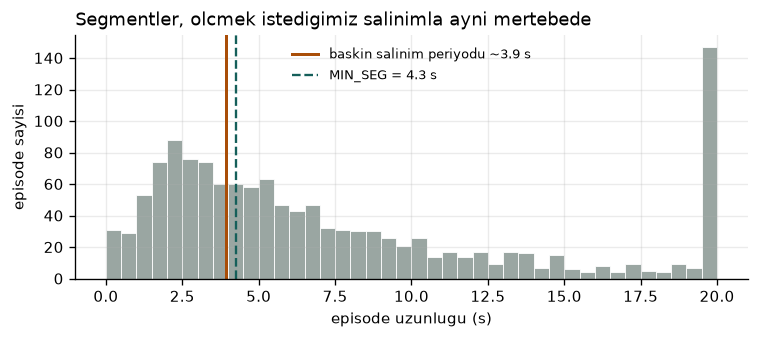

In [11]:
L = s.groupby(["participant_id", "trial_id", "episode"]).size()
Ls = L / FS
print(f"episode sayisi        : {len(L):,}")
print(f"medyan uzunluk        : {Ls.median():.1f} s")
print(f"ortalama uzunluk      : {Ls.mean():.1f} s")
print(f">= {MIN_SEG/FS:.1f} s olan : {(L >= MIN_SEG).sum():,} / {len(L):,} "
      f"({100*(L >= MIN_SEG).mean():.0f}%)")
print(f">= 8.5 s olan         : {(L >= 512).sum():,} / {len(L):,} "
      f"({100*(L >= 512).mean():.0f}%)")
print()
print(f"Olculen medyan frekans ~{pc.medfreq_angle.mean():.2f} Hz "
      f"= ~{1/pc.medfreq_angle.mean():.1f} s periyot")
print(f"Segmentlerin medyani   ~{Ls.median():.1f} s")
print("Yani tipik bir segmentte baskin salinimin ancak BIR donusu var.")

fig, ax = plt.subplots(figsize=(6.4, 2.9))
ax.hist(Ls, bins=np.arange(0, 20.5, 0.5), color="#9AA6A2", edgecolor="white", linewidth=0.5)
ax.axvline(1 / pc.medfreq_angle.mean(), color="#A94E08", lw=1.8,
           label=f"baskin salinim periyodu ~{1/pc.medfreq_angle.mean():.1f} s")
ax.axvline(MIN_SEG / FS, color="#155F5A", lw=1.4, ls="--",
           label=f"MIN_SEG = {MIN_SEG/FS:.1f} s")
ax.set_xlabel("episode uzunlugu (s)")
ax.set_ylabel("episode sayisi")
ax.set_title("Segmentler, olcmek istedigimiz salinimla ayni mertebede", loc="left")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

## 7. Kontrol ölçütleri performansın kopyası mı

Bir ölçüt performansla yüksek korelasyonluysa, ayrı bir bilgi taşımıyor demektir; sadece
`mae_angle_deg`'i başka isimle raporlamış olursun. Kişi içi merkezlenmiş korelasyon.

In [12]:
tm = pd.read_parquet(INTERIM / "trial_metrics.parquet")
m = trial.merge(tm[["participant_id", "trial_id", "mae_angle_deg"]],
                on=["participant_id", "trial_id"], how="left")

out = []
for c in METRICS:
    d = m.dropna(subset=[c, "mae_angle_deg"]).copy()
    a = d.groupby("participant_id")[c].transform(lambda v: v - v.mean())
    b = d.groupby("participant_id")["mae_angle_deg"].transform(lambda v: v - v.mean())
    out.append((c, round(float(np.corrcoef(a, b)[0, 1]), 3)))

print(pd.DataFrame(out, columns=["olcut", "r (performansla)"]).to_string(index=False))

          olcut  r (performansla)
  medfreq_angle            -0.052
  medfreq_input            -0.400
   sampen_angle            -0.114
   sampen_input             0.402
medfreq_cartpos             0.057
 sampen_cartpos             0.069
medfreq_cartvel            -0.221
 sampen_cartvel             0.171
     duty_cycle             0.598
       amp_mean             0.502
     iai_median            -0.152
         iai_cv             0.081
     onset_rate             0.238


`duty_cycle` (r = 0.63) büyük ölçüde performansın kopyası: kötü giden kişi daha çok
müdahale ediyor. `medfreq_angle` ise performanstan neredeyse bağımsız (r ≈ 0.00), yani
ayrı bir bilgi taşıyor. Ölçüt olarak değeri var, sadece bu segment uzunluğunda güvenilir
kestirilemiyor.

## Ölçüt güvenilirliği: ICC ve split-half

Kontrast testleri "koşul etkisi var mı" diye soruyor. Bu bölüm ondan önce gelen soruyu
soruyor: **bu ölçütler zaten güvenilir mi?** Güvenilir olmayan bir ölçütte null sonuç,
etkinin yokluğunu değil ölçümün gürültüsünü gösterir.

İki hesap, ikisi de NB92'de yazıldı ve `src/reliability.py`'ye taşındı; buraya import
ediliyor, kopyalanmıyor:

- **ICC(2,1)**: ölçümün ne kadarı kişinin kalıcı özelliği. Kişi × koşul tablosundaki
  varyans ayrışımından çıkıyor.
- **Split-half**: her kişinin her koşuldaki denemeleri rastgele ikiye bölünüp iki yarı
  karşılaştırılıyor, 200 tekrar. *Genel seviye r*, kişinin beş koşul ortalamasının iki
  yarıda tutup tutmadığı; *koşul sıralaması rho*, o kişinin koşul sıralamasının tutup
  tutmadığı. İlki tutup ikincisi tutmuyorsa ölçüm kişileri ayırabiliyor ama o kişinin
  koşullarını ayıramıyor demektir.

NB92'deki `ayni_en_iyi_pct` burada raporlanmıyor: o kolon ölçütün "iyi" yönünün tanımlı
olmasını gerektiriyor, medyan frekans ya da entropy için böyle bir yön yok.

In [13]:
rel = []
for m in METRICS:
    d = trial.dropna(subset=[m])
    ct = (d.groupby(["participant_id", "noise_level_id"]).size()
            .unstack().reindex(columns=COND))
    if ct.isna().any().any() or (ct.fillna(0) < 2).any().any():
        rel.append(dict(olcut=m, n=np.nan, ICC=np.nan, genel_seviye_r=np.nan,
                        kosul_siralamasi_rho=np.nan, aciklama="hucre basina <2 trial"))
        continue
    dec = decompose(cell_table(pc, m))
    # sign yalnizca burada raporlamadigimiz ayni_en_iyi_pct'yi etkiler.
    sh = split_half_stats(d, m, sign=-1)
    rel.append(dict(olcut=m, n=dec["n"], ICC=round(dec["ICC"], 2),
                    genel_seviye_r=round(sh["genel_seviye_r"], 2),
                    kosul_siralamasi_rho=round(sh["kosul_siralamasi_rho"], 2),
                    aciklama=""))

print(f"OLCUT GUVENILIRLIGI  (split-half {N_SPLIT_DEFAULT} tekrar)")
print()
print(pd.DataFrame(rel).to_string(index=False))

OLCUT GUVENILIRLIGI  (split-half 200 tekrar)

          olcut  n  ICC  genel_seviye_r  kosul_siralamasi_rho aciklama
  medfreq_angle 10 0.59            0.86                  0.20         
  medfreq_input 10 0.96            0.98                  0.03         
   sampen_angle 10 0.84            0.95                  0.06         
   sampen_input 10 0.37            0.45                 -0.18         
medfreq_cartpos 10 0.47            0.64                 -0.01         
 sampen_cartpos 10 0.83            0.93                  0.05         
medfreq_cartvel 10 0.88            0.95                 -0.04         
 sampen_cartvel 10 0.63            0.82                 -0.05         
     duty_cycle 10 0.94            0.98                  0.04         
       amp_mean 10 0.99            0.99                 -0.30         
     iai_median 10 0.95            0.97                 -0.28         
         iai_cv 10 0.55            0.71                 -0.16         
     onset_rate 10 0.91        

## 8. Sonuç

**Bu veride kontrol tarafında koşul etkisi bulunamadı.**

- Girdinin yapısına dair hiçbir ölçüt (duty cycle, genlik, aksiyonlar arası süre ve
  değişkenliği, aksiyon oranı, girdi entropy'si, girdi spektrumu) koşullara göre değişmiyor.
- Açı sinyalindeki iki ölçüt ham halde p < 0.05 veriyor ama ikisi de sağlamlık taramasını
  geçemiyor, ve dokuz ölçüt sınandığı için Holm sonrası zaten ayakta kalmıyorlar.
- Kuadratik kontrast hiçbir ölçütte anlamlı değil. Yani kontrol tarafında da ters U yok;
  pilotun ana bulgusuyla tutarlı.

**Yöntemsel bulgu, asıl çıktı bu.** Frekans analizi bu veriye bu haliyle uygulanamıyor.
Çubuğun baskın salınım periyodu ~4 saniye, episode'ların medyanı da ~4.3 saniye. Tipik bir
segmentte salınımın ancak bir dönüşü var, bu da spektrum kestirimini çözünürlük sınırına
itiyor. Episode'ların yarısı zaten MIN_SEG'in altında kaldığı için analize hiç girmiyor.

**Ne yapılabilir**

1. **Zaman düzleminde kalmak.** Aynı soruya (kişi ne sıklıkta ve ne kadar sürede düzeltiyor)
   spektrum yerine doğrudan cevap veren yöntemler var ve kısa segmentlerde çalışıyorlar.
   En uygunu Collins & De Luca'nın diffusion analizi: açı serisini random walk olarak ele
   alıp kısa ve uzun vadeli difüzyon katsayılarını ve aralarındaki kritik noktayı çıkarıyor.
   "Katılımcı ne kadar süre düzeltmeden bırakıyor" sorusuna doğrudan sayı veriyor.
   *Collins & De Luca 1993, Exp Brain Res 95(2):308.*
2. **Ana deneyde daha uzun kesintisiz segment.** Düşüş episode'u bitirdiği için segment
   uzunluğu doğrudan performansa bağlı, yani iyi dengeleyenin uzun segmenti oluyor. Bu tek
   başına bir yanlılık kaynağı. Ana deney uzun olacaksa ve zorluk kademeli artacaksa,
   erken bloklarda uzun segmentler beklenebilir.
3. **Aksiyon segmenti düzeyine inmek.** Her onset-offset segmenti için tepe genlik, süre ve
   tetikleyen durum (θ, ω). Bu spektrum gerektirmiyor ve `input_events` tablosu zaten hazır.

**Not.** Bu notebook bir keşif taraması; hiçbir sonucu karar setine girmez. Değeri, hangi
yöntemin bu veriye uyup uymadığını ölçmüş olması.